# 06 — EDA focalizado en los 3 municipios foco

**Proyecto:** Detección de excesos epidemiológicos de dengue en Colombia
**Maestría en IA — Desarrollo de Soluciones**

Este notebook explora visualmente el panel municipal-mensual (2007-2024) construido
en `scripts/construir_panel.py`, restringido a los 3 municipios foco:

| DIVIPOLA | Municipio | Depto | Región |
|---|---|---|---|
| 23855 | Valencia | Córdoba | Caribe |
| 47288 | Fundación | Magdalena | Sierra Nevada |
| 95025 | El Retorno | Guaviare | Amazonía |

**Objetivo del EDA:** responder 3 preguntas antes de modelar (Paso 5):

1. ¿Cómo se ve la serie de casos por municipio? ¿Hay huecos, brotes claros, estacionalidad?
2. ¿El target con `percentil 75 histórico` es útil, o está saturado por meses-cero?
3. ¿Qué variables climáticas (y con qué lag) correlacionan con casos?

Las decisiones D11–D14 que enmarcan este análisis están documentadas en
`docs/decisiones_proyecto.md`.


In [1]:
import sys, os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

sys.path.insert(0, os.path.join("..", "src"))
from utils import MUNICIPIOS_FOCO, PROJECT_ROOT, configurar_estilo

configurar_estilo()
pd.set_option("display.max_columns", 50)

OUT_DIR = PROJECT_ROOT / "results_graphs" / "foco"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Cargar panel desde parquet (mucho más rápido que CSV)
panel = pd.read_parquet(PROJECT_ROOT / "data/processed/panel_municipal_mensual.parquet")
panel["fecha"] = pd.to_datetime(dict(year=panel["ano"], month=panel["mes"], day=1))
panel = panel.sort_values(["cod_mpio", "fecha"]).reset_index(drop=True)

COLOR = {"23855": "#1f77b4", "47288": "#d62728", "95025": "#2ca02c"}
print(f"Panel: {panel.shape[0]:,} filas × {panel.shape[1]} columnas")
print(f"Municipios: {list(MUNICIPIOS_FOCO.values())}")
panel.head(3)


Panel: 648 filas × 43 columnas
Municipios: ['Valencia', 'Fundación', 'El Retorno']


,cod_mpio,ano,mes,municipio,casos_total,casos_regular,casos_grave,hospitalizaciones,fallecidos,dpto_clima,temperatura_c,precipitacion_mm,ndvi,dewpoint_c,poblacion,incidencia_x100k,umbral_p75,exceso,temperatura_c_lag1,temperatura_c_lag2,temperatura_c_lag3,temperatura_c_mm3,precipitacion_mm_lag1,precipitacion_mm_lag2,precipitacion_mm_lag3,precipitacion_mm_mm3,ndvi_lag1,ndvi_lag2,ndvi_lag3,ndvi_mm3,dewpoint_c_lag1,dewpoint_c_lag2,dewpoint_c_lag3,dewpoint_c_mm3,casos_total_lag1,casos_total_lag2,casos_total_lag3,casos_total_mm3,incidencia_x100k_lag1,incidencia_x100k_lag2,incidencia_x100k_lag3,incidencia_x100k_mm3,fecha
0,23855,2007,1,Valencia,0,0,0,0,0,CORDOBA,30.69,14.53,0.6397,22.99,31902.0,0.0,NaN,<NA>,NaN,NaN,NaN,30.690000,NaN,NaN,NaN,14.53,NaN,NaN,NaN,0.639700,NaN,NaN,NaN,22.990,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2007-01-01
1,23855,2007,2,Valencia,0,0,0,0,0,CORDOBA,33.18,13.43,0.5492,21.26,31902.0,0.0,NaN,<NA>,30.69,NaN,NaN,31.935000,14.53,NaN,NaN,13.98,0.6397,NaN,NaN,0.594450,22.99,NaN,NaN,22.125,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,2007-02-01
2,23855,2007,3,Valencia,0,0,0,0,0,CORDOBA,33.85,95.67,0.4166,22.62,31902.0,0.0,NaN,<NA>,33.18,30.69,NaN,32.573333,13.43,14.53,NaN,41.21,0.5492,0.6397,NaN,0.535167,21.26,22.99,NaN,22.290,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,2007-03-01


## 1. Calidad del dato

Cobertura por municipio-año y meses con cero casos.


In [2]:
# Resumen general
resumen = []
for cod, nom in tqdm(MUNICIPIOS_FOCO.items(), desc="Resumen por municipio"):
    sub = panel[panel["cod_mpio"] == cod]
    resumen.append({
        "municipio": nom,
        "meses_total": len(sub),
        "meses_con_casos": (sub["casos_total"] > 0).sum(),
        "%_meses_cero": (sub["casos_total"] == 0).mean() * 100,
        "casos_totales": int(sub["casos_total"].sum()),
        "casos_promedio_mensual": sub["casos_total"].mean(),
        "casos_max_mes": int(sub["casos_total"].max()),
        "casos_graves": int(sub["casos_grave"].sum()),
    })
pd.DataFrame(resumen).round(2)


Resumen por municipio:   0%|          | 0/3 [00:00<?, ?it/s]

,municipio,meses_total,meses_con_casos,%_meses_cero,casos_totales,casos_promedio_mensual,casos_max_mes,casos_graves
0,Valencia,216,129,40.28,1379,6.38,100,3
1,Fundación,216,152,29.63,2217,10.26,117,19
2,El Retorno,216,124,42.59,798,3.69,94,14


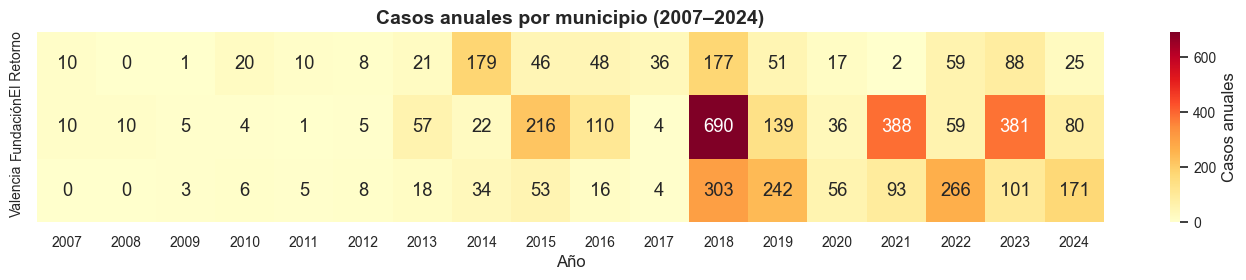

In [3]:
# Heatmap: casos por (municipio × año)
casos_ano = panel.groupby(["municipio", "ano"])["casos_total"].sum().unstack()
fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(casos_ano, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "Casos anuales"})
ax.set_title("Casos anuales por municipio (2007–2024)", fontweight="bold")
ax.set_xlabel("Año"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUT_DIR / "01_casos_por_ano_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


## 2. Series temporales por municipio

Una serie mensual por municipio, con marcadores en los meses clasificados como
"exceso" según el target actual (`casos > p75 histórico del mes`).


Series temporales:   0%|          | 0/3 [00:00<?, ?it/s]

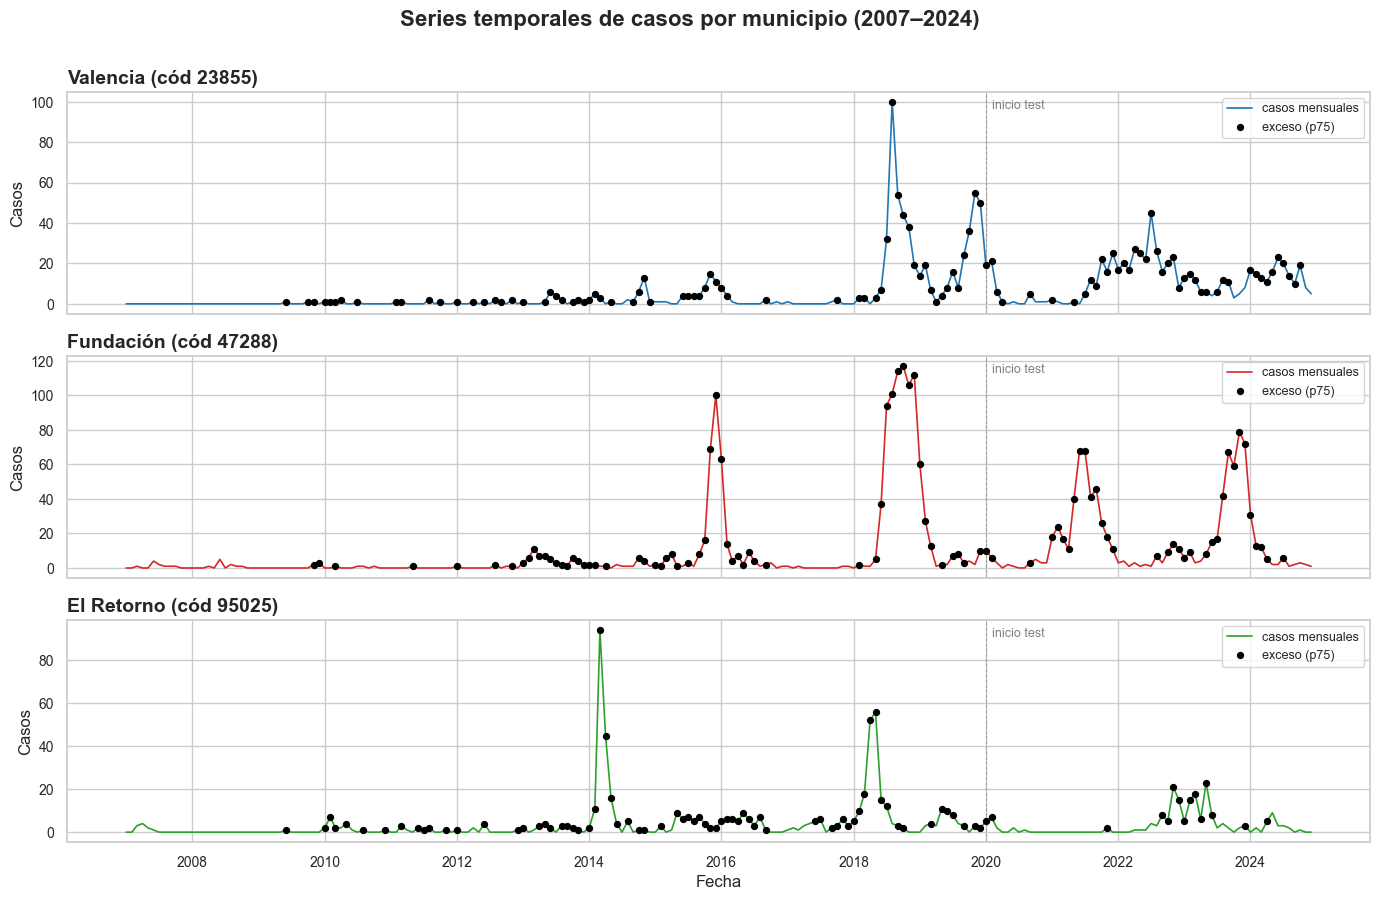

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, (cod, nom) in zip(axes, tqdm(MUNICIPIOS_FOCO.items(), desc="Series temporales")):
    sub = panel[panel["cod_mpio"] == cod].sort_values("fecha")
    ax.plot(sub["fecha"], sub["casos_total"], color=COLOR[cod], lw=1.2,
            label="casos mensuales")
    excesos = sub[sub["exceso"] == 1]
    ax.scatter(excesos["fecha"], excesos["casos_total"], color="black",
               s=18, zorder=5, label="exceso (p75)")
    ax.axvline(pd.Timestamp("2020-01-01"), color="gray", lw=0.7,
               linestyle="--", alpha=0.6)
    ax.text(pd.Timestamp("2020-02-01"), ax.get_ylim()[1] * 0.92,
            "inicio test", color="gray", fontsize=9)
    ax.set_title(f"{nom} (cód {cod})", fontweight="bold", loc="left")
    ax.set_ylabel("Casos")
    ax.legend(loc="upper right", fontsize=9)

axes[-1].set_xlabel("Fecha")
fig.suptitle("Series temporales de casos por municipio (2007–2024)",
             fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(OUT_DIR / "02_series_temporales.png", dpi=120, bbox_inches="tight")
plt.show()


## 3. Comparativo de definiciones de target

Comparamos 3 alternativas para el target binario `exceso`:

- **A — p75 sin piso (actual):** `casos > p75_hist(mes)`
- **B — p75 con piso 2:** `casos > max(p75_hist(mes), 2)` — evita que meses con historial de cero disparen alertas con 1 caso.
- **C — p90 sin piso:** `casos > p90_hist(mes)` — eventos más raros, más específicos.

Para cada alternativa, mostramos prevalencia global y por municipio.


In [5]:
def calcular_umbral_historico(g, q):
    casos = g["casos_total"].values
    anos = g["ano"].values
    out = np.full(len(g), np.nan)
    for i in range(len(g)):
        hist = casos[anos < anos[i]]
        if len(hist) >= 2:
            out[i] = np.percentile(hist, q)
    return pd.Series(out, index=g.index)

# Calculamos las 3 alternativas con tqdm sobre las combinaciones
alternativas = {
    "A: p75 sin piso":    {"q": 75, "piso": None},
    "B: p75 con piso 2":  {"q": 75, "piso": 2},
    "C: p90 sin piso":    {"q": 90, "piso": None},
}

resultados = panel[["cod_mpio", "municipio", "ano", "mes", "casos_total"]].copy()
for nombre, cfg in tqdm(alternativas.items(), desc="Calculando targets"):
    umbral = (
        resultados.groupby(["cod_mpio", "mes"], group_keys=False)
        .apply(lambda g: calcular_umbral_historico(g, cfg["q"]))
    )
    # groupby.apply puede devolver el resultado en orden de grupos, no de filas
    # originales → re-alinear al index de `resultados` antes de comparar.
    umbral = umbral.reindex(resultados.index)
    if cfg["piso"] is not None:
        umbral = umbral.where(umbral.isna(), umbral.clip(lower=cfg["piso"]))
    resultados[nombre] = (resultados["casos_total"] > umbral).astype("Int64")
    resultados.loc[umbral.isna(), nombre] = pd.NA

# Tabla de prevalencias
tabla = []
for nombre in alternativas:
    fila = {"target": nombre, "prevalencia_global_%": float(resultados[nombre].mean()) * 100}
    for cod, nom in MUNICIPIOS_FOCO.items():
        sub = resultados[resultados["cod_mpio"] == cod]
        fila[nom] = float(sub[nombre].mean()) * 100
    tabla.append(fila)
pd.DataFrame(tabla).round(1)


Calculando targets:   0%|          | 0/3 [00:00<?, ?it/s]

,target,prevalencia_global_%,Valencia,Fundación,El Retorno
0,A: p75 sin piso,50.3,57.3,48.4,45.3
1,B: p75 con piso 2,36.8,39.6,38.5,32.3
2,C: p90 sin piso,35.2,42.7,30.7,32.3


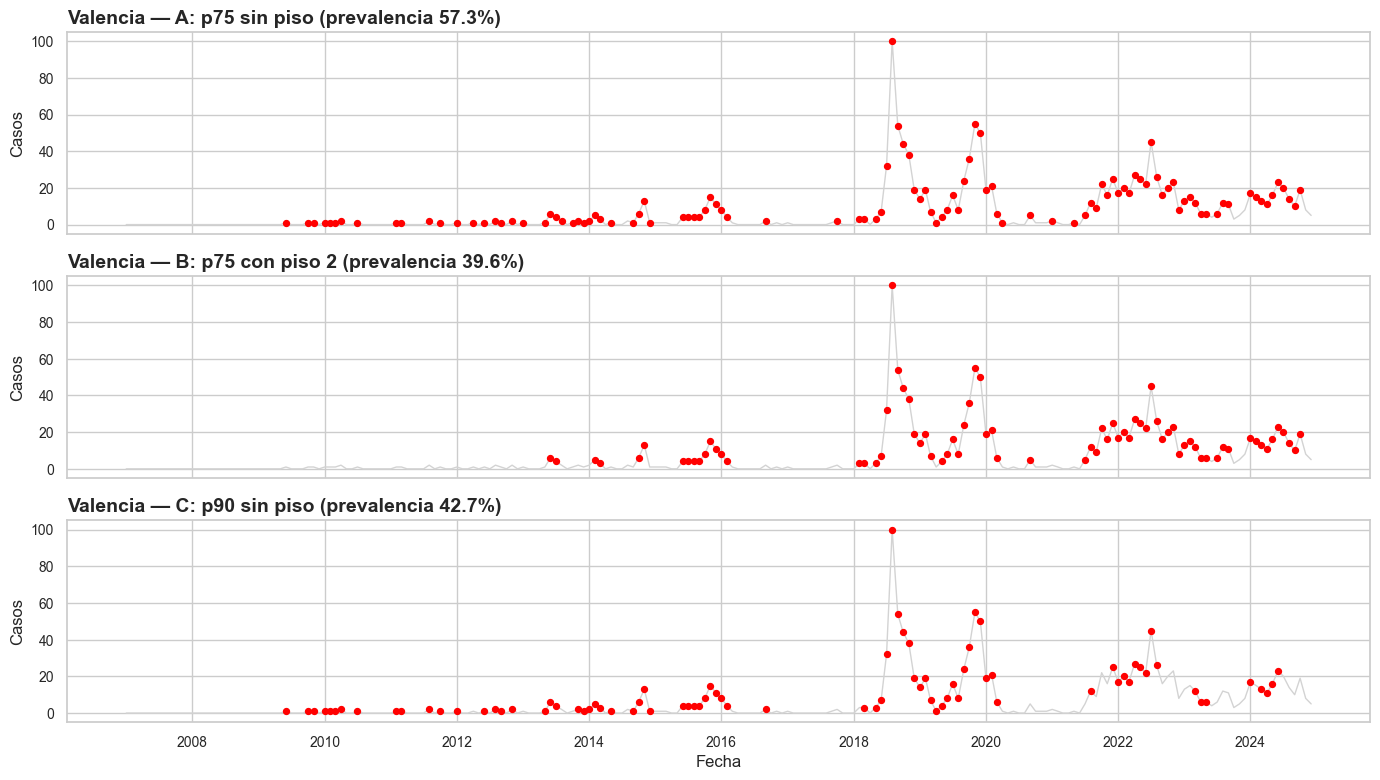

In [6]:
# Visualizar las 3 definiciones sobre Valencia (el más activo) para ver diferencia
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
sub_val = resultados[resultados["cod_mpio"] == "23855"].sort_values(["ano", "mes"])
sub_val["fecha"] = pd.to_datetime(dict(year=sub_val["ano"], month=sub_val["mes"], day=1))

for ax, nombre in zip(axes, alternativas):
    ax.plot(sub_val["fecha"], sub_val["casos_total"], color="lightgray", lw=1)
    exc = sub_val[sub_val[nombre] == 1]
    ax.scatter(exc["fecha"], exc["casos_total"], color="red", s=18, zorder=5)
    prev = float(sub_val[nombre].mean()) * 100
    ax.set_title(f"Valencia — {nombre} (prevalencia {prev:.1f}%)",
                 fontweight="bold", loc="left")
    ax.set_ylabel("Casos")
axes[-1].set_xlabel("Fecha")
plt.tight_layout()
plt.savefig(OUT_DIR / "03_target_comparativo_valencia.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. Estacionalidad

Distribución de casos por mes calendario, agregando todos los años. Muestra si
hay un pico estacional claro y si los 3 municipios siguen el mismo patrón.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.


...

findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['DejaVu Sans Mono'] not found. Falling back to DejaVu Sans.


findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


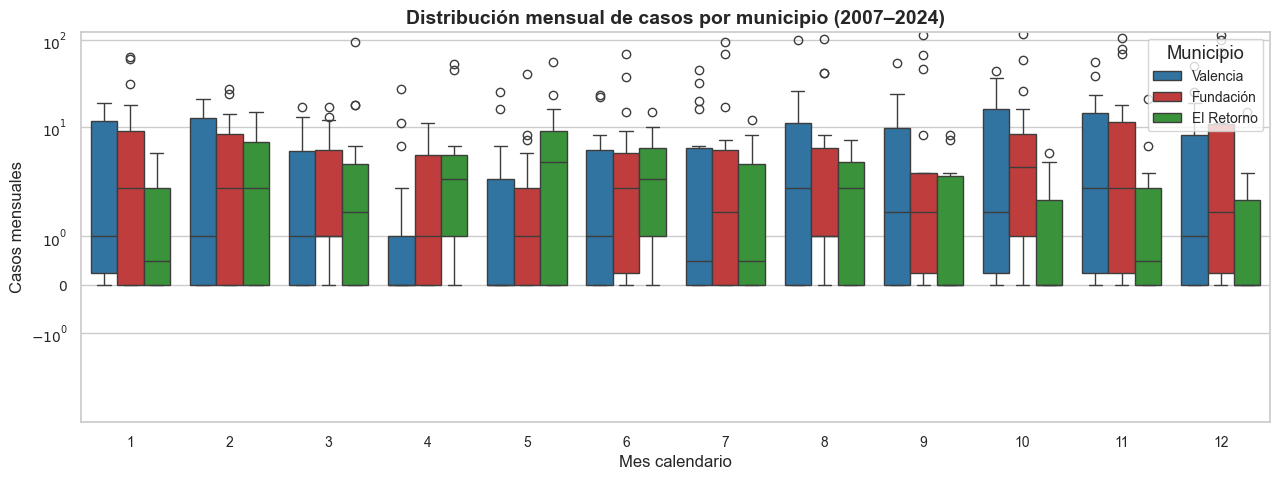

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))
data_long = panel[["municipio", "mes", "casos_total"]].copy()
sns.boxplot(data=data_long, x="mes", y="casos_total", hue="municipio",
            palette=[COLOR[c] for c in MUNICIPIOS_FOCO], ax=ax)
ax.set_title("Distribución mensual de casos por municipio (2007–2024)",
             fontweight="bold")
ax.set_xlabel("Mes calendario"); ax.set_ylabel("Casos mensuales")
ax.set_yscale("symlog")
ax.legend(title="Municipio", loc="upper right")
plt.tight_layout()
plt.savefig(OUT_DIR / "04_estacionalidad_boxplot.png", dpi=120, bbox_inches="tight")
plt.show()


## 5. Correlación clima ↔ casos por lag

Para cada municipio, calculamos la correlación de Spearman entre `casos_total`
y cada variable climática en lag 0, 1, 2, 3 meses. La señal útil para el modelo
es la correlación con lag positivo (clima del pasado predice casos del presente).


Correlaciones por municipio:   0%|          | 0/3 [00:00<?, ?it/s]

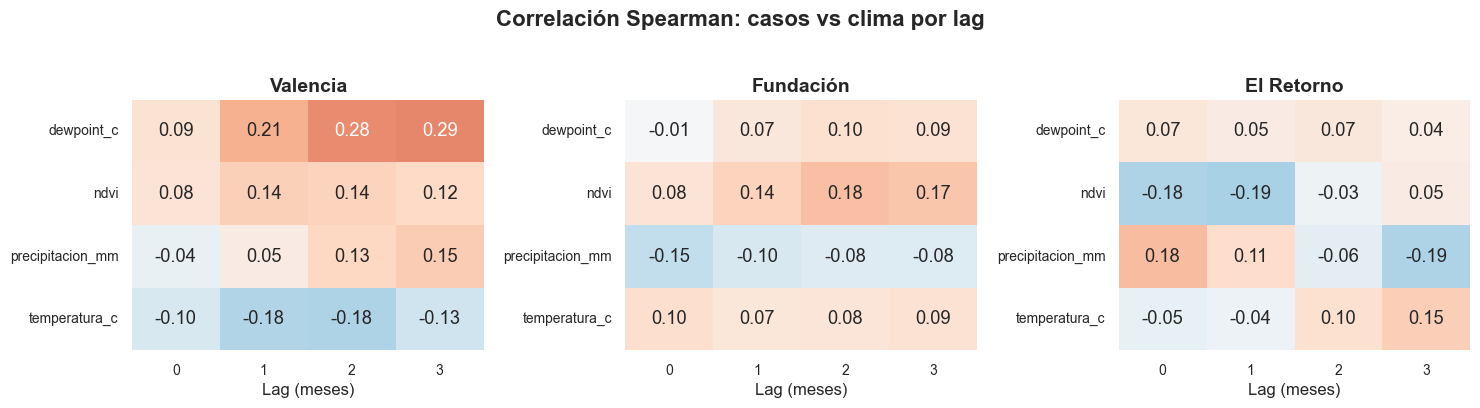

In [8]:
vars_clima = ["temperatura_c", "precipitacion_mm", "ndvi", "dewpoint_c"]
lags = [0, 1, 2, 3]

correlaciones = []
for cod, nom in tqdm(MUNICIPIOS_FOCO.items(), desc="Correlaciones por municipio"):
    sub = panel[panel["cod_mpio"] == cod].sort_values("fecha")
    for var in vars_clima:
        for L in lags:
            col_lag = f"{var}_lag{L}" if L > 0 else var
            if col_lag not in sub.columns:
                continue
            r = sub["casos_total"].corr(sub[col_lag], method="spearman")
            correlaciones.append({"municipio": nom, "variable": var,
                                  "lag": L, "spearman": r})

df_corr = pd.DataFrame(correlaciones)

# Heatmap por municipio
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (cod, nom) in zip(axes, MUNICIPIOS_FOCO.items()):
    sub = df_corr[df_corr["municipio"] == nom]
    pivot = sub.pivot(index="variable", columns="lag", values="spearman")
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                vmin=-0.6, vmax=0.6, ax=ax, cbar=False)
    ax.set_title(nom, fontweight="bold")
    ax.set_xlabel("Lag (meses)")
    ax.set_ylabel("")

fig.suptitle("Correlación Spearman: casos vs clima por lag",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "05_correlacion_clima_lag.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Auto-correlación de casos (memoria de la serie)

¿Qué tan informativo es el conteo del mes pasado para predecir el actual? Esto
valida si los lags de `casos_total` que ya incluimos en el panel son útiles
como features.


Autocorrelación:   0%|          | 0/3 [00:00<?, ?it/s]

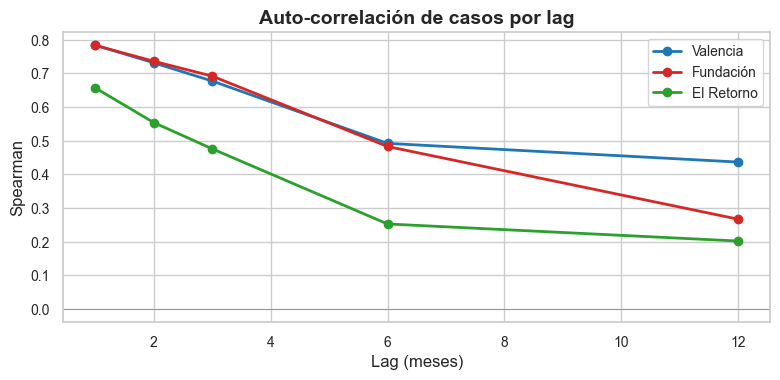

In [9]:
auto_corr = []
for cod, nom in tqdm(MUNICIPIOS_FOCO.items(), desc="Autocorrelación"):
    sub = panel[panel["cod_mpio"] == cod].sort_values("fecha")
    for L in [1, 2, 3, 6, 12]:
        r = sub["casos_total"].corr(sub["casos_total"].shift(L), method="spearman")
        auto_corr.append({"municipio": nom, "lag_meses": L, "spearman": r})

df_auto = pd.DataFrame(auto_corr)
fig, ax = plt.subplots(figsize=(8, 4))
for (cod, nom), color in zip(MUNICIPIOS_FOCO.items(),
                             [COLOR[c] for c in MUNICIPIOS_FOCO]):
    sub = df_auto[df_auto["municipio"] == nom]
    ax.plot(sub["lag_meses"], sub["spearman"], marker="o", lw=2,
            label=nom, color=color)
ax.axhline(0, color="gray", lw=0.5)
ax.set_title("Auto-correlación de casos por lag", fontweight="bold")
ax.set_xlabel("Lag (meses)"); ax.set_ylabel("Spearman")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "06_autocorrelacion_casos.png", dpi=120, bbox_inches="tight")
plt.show()


## 7. Conclusiones del EDA (preliminares)

> ⚠️ **Esta celda es para llenar después de ver los gráficos arriba.** Edítala
> con las decisiones específicas que se desprenden del análisis. Plantilla:

### Calidad del dato
- _[Municipio X tuvo Y huecos en el año Z, …]_
- _[Casos graves son tan raros que solo aportan información descriptiva — confirma D13.]_

### Target a usar en modelado
- _[Elegido: A / B / C — razón:]_

### Features climáticas con mayor potencial
- Por **Valencia**: _[ej. precipitacion_mm con lag 2 (ρ = …)]_
- Por **Fundación**: _[…]_
- Por **El Retorno**: _[…]_

### Auto-regresión: ¿incluir lags de casos como features?
- _[Decisión: sí/no, basada en si la autocorrelación cae rápido o no]_

### Próximos pasos
1. Aplicar el target elegido al panel y regenerar (si cambia).
2. Pasar al Paso 5 — modelado per-municipio con split cronológico.
